# Inflation Forecasting — Gradient Boosted Trees (HistGradientBoostingRegressor)

Tunes `learning_rate` and `max_depth` jointly via `GridSearchCV` with
`TimeSeriesSplit`, mirroring the ElasticNet notebook's tuning strategy.
Saves test-set predictions to `results/gbt_preds.npy` for `model_comparison.ipynb`.

**Metrics scale:** monthly log-diff × 100 (percentage points of monthly PCE inflation).


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from fred_md_utils import configure_plots, default_paths, get_splits

configure_plots()
VINTAGE_DIR, RESULTS_DIR = default_paths()


## Load splits

In [2]:
vintage_file, X_train, y_train, X_val, y_val, X_test, y_test, feature_names = get_splits(
    VINTAGE_DIR, horizon=1, n_lags=0,
)
print(f"Features: {len(feature_names)}  Train/Val/Test: {len(X_train)}/{len(X_val)}/{len(X_test)}")


  2026-04-MD.csv: URL returned HTML — vintage not yet published
Already have 2026-03-MD.csv

Dataset summary (PCEPI first-log-diff target, 1-month-ahead):
  Train :  768 obs  1959-01-01 -> 2022-12-01
  Val   :   29 obs  2023-01-01 -> 2025-05-01
  Test  :    7 obs  2025-06-01 -> 2025-12-01
  Features: 126 (126 base × 1 time steps)
Features: 126  Train/Val/Test: 768/29/7


## Joint grid search: `learning_rate` × `max_depth`

Uses `TimeSeriesSplit(n_splits=5)` on the training set and scores with
negative RMSE. `GridSearchCV` refits the best model on the full training set.


In [3]:
param_grid = {
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15],
    'max_depth':     [3, 4, 5, 6, 8],
}

base = HistGradientBoostingRegressor(
    max_iter=1000,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=0.1,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=25,
    random_state=42,
)

tscv = TimeSeriesSplit(n_splits=5)
grid = GridSearchCV(
    base, param_grid, cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, refit=True,
)
grid.fit(X_train, y_train)

print(f"Best params : {grid.best_params_}")
print(f"Best CV RMSE: {-grid.best_score_:.4f}")

model = grid.best_estimator_


Best params : {'learning_rate': 0.15, 'max_depth': 6}
Best CV RMSE: 0.2670


## Predict and evaluate

In [4]:
val_pred  = model.predict(X_val)
test_pred = model.predict(X_test)

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return {
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE':  float(mean_absolute_error(y_true, y_pred)),
        'R²':   float(r2_score(y_true, y_pred)),
        'MAPE': float(np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100),
    }

val_m  = metrics(y_val,  val_pred)
test_m = metrics(y_test, test_pred)
naive_rmse = float(np.sqrt(mean_squared_error(y_val.iloc[1:], y_val.shift(1).dropna())))

print(f"Val  : RMSE={val_m['RMSE']:.4f}  MAE={val_m['MAE']:.4f}  R²={val_m['R²']:.4f}  MAPE={val_m['MAPE']:.2f}%")
print(f"Test : RMSE={test_m['RMSE']:.4f}  MAE={test_m['MAE']:.4f}  R²={test_m['R²']:.4f}  MAPE={test_m['MAPE']:.2f}%")
print(f"Naive RW (val reference) RMSE: {naive_rmse:.4f}")


Val  : RMSE=0.1174  MAE=0.0949  R²=0.0458  MAPE=219.85%
Test : RMSE=0.0767  MAE=0.0662  R²=-0.8058  MAPE=26.65%
Naive RW (val reference) RMSE: 0.1661


## Plot actual vs predicted

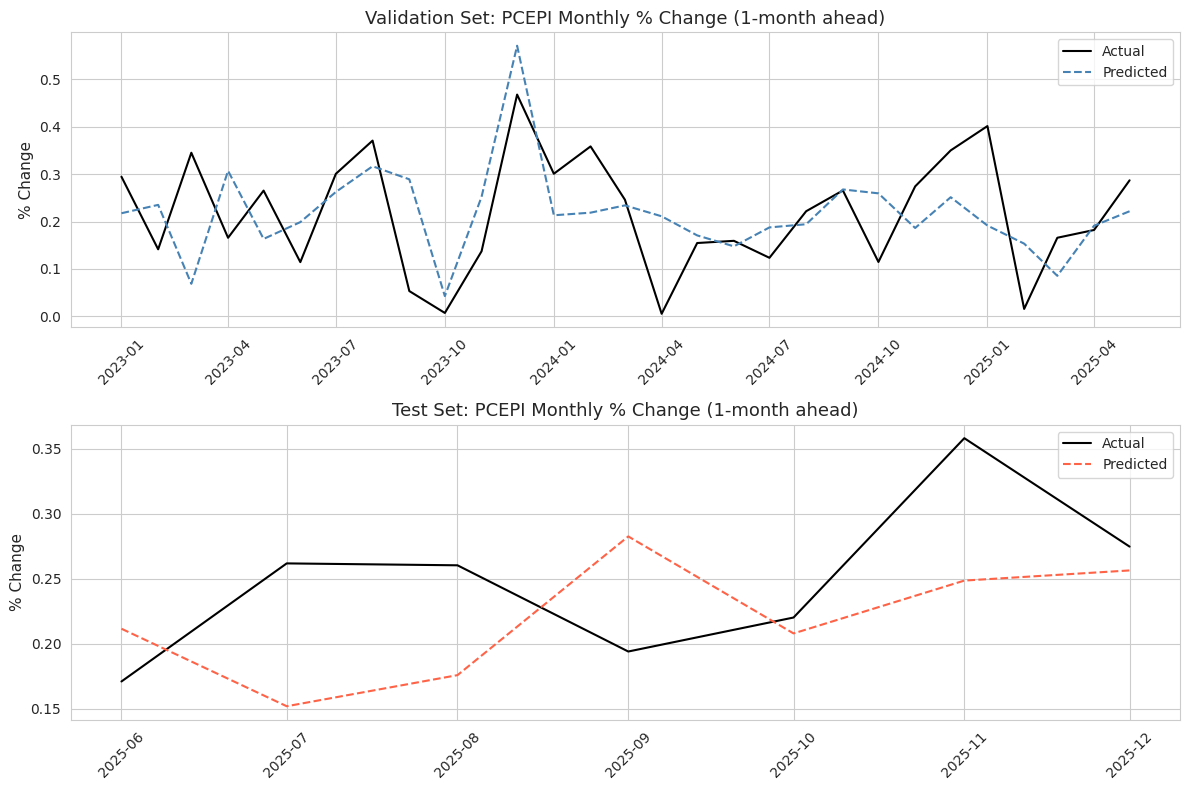

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(y_val.index, y_val.values, label='Actual', color='black')
axes[0].plot(y_val.index, val_pred,     label='Predicted', color='steelblue', linestyle='--')
axes[0].set_title('Validation Set: PCEPI Monthly % Change (1-month ahead)')
axes[0].set_ylabel('% Change')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(y_test.index, y_test.values, label='Actual', color='black')
axes[1].plot(y_test.index, test_pred,     label='Predicted', color='tomato', linestyle='--')
axes[1].set_title('Test Set: PCEPI Monthly % Change (1-month ahead)')
axes[1].set_ylabel('% Change')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## Save test predictions for `model_comparison.ipynb`

In [6]:
os.makedirs(RESULTS_DIR, exist_ok=True)
np.save(os.path.join(RESULTS_DIR, 'gbt_preds.npy'), np.asarray(test_pred))
np.save(os.path.join(RESULTS_DIR, 'gbt_dates.npy'),
        np.array(y_test.index, dtype='datetime64[ns]'))
print(f"Saved {len(test_pred)} GBT predictions to {RESULTS_DIR}/gbt_preds.npy")
print(f"  {y_test.index.min().date()} -> {y_test.index.max().date()}")


Saved 7 GBT predictions to results/gbt_preds.npy
  2025-06-01 -> 2025-12-01
